# RefineU: Graph UNet for Brain Graph Super-Resolution

This notebook demonstrates the **training pipeline for a single model configuration** — **RefineU-B-Gated** (Graph UNet with betweenness centrality features and gated skip connections). In the full project we train and compare multiple model variants (see report), but this notebook focuses on one end-to-end run.

## Project Structure

```
refine_u/
├── configs/                  # Hydra YAML configs (model, training, experiments)
├── models/                   # PyTorch model definitions (RefineU, DEFEND, GSRN)
├── pipelines/                # Training pipelines per model family
├── plot_scripts/             # Ablation and comparison plots
├── data/                     # Train/test CSVs + cached features
├── outputs/                  # Per-experiment fold predictions & submissions
├── train.py                  # Hydra-based CLI training entry point
├── evaluate.py               # Loss functions & evaluation metrics
├── evaluation_plots.ipynb    # Full 8-metric evaluation across all models
├── evaluation_results.json   # Precomputed evaluation metrics (all configs)
└── RefineU.ipynb             # ← This notebook (single model training demo)
```

The CLI (`train.py`) uses Hydra to compose configs and supports all model variants. This notebook bypasses Hydra to run everything inline for clarity.

## 1. Reproducibility Configuration

In [3]:
import copy
import os
import random

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.spatial.distance import jensenshannon
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available. Using GPU.")
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU.")

CUDA is available. Using GPU.


## 2. Hyperparameters

In [4]:
# ---------------------------------------------------------------------------
# Model hyperparameters
# ---------------------------------------------------------------------------
LR_DIM = 160          # Low-resolution graph nodes
HR_DIM = 268          # High-resolution graph nodes
GCN_HIDDEN = 64       # GCN hidden dimension
GCN_OUT = 32          # GCN output dimension
MLP_HIDDEN = 256      # MLP hidden dimension
DROPOUT = 0.2         # Dropout rate
POOL_RATIOS = [0.7, 0.7, 0.7, 0.7]  # TopK pooling ratios per UNet level
GATED_SKIP = True     # Use learned gating for skip connections
OUTPUT_ACTIVATION = "leaky_relu"  # Output activation (leaky_relu | relu | none)

# ---------------------------------------------------------------------------
# Training hyperparameters
# ---------------------------------------------------------------------------
EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4
ETA_MIN = 1e-5        # Cosine annealing minimum LR
LOSS_TYPE = "mixed"   # mixed = 0.5*MSE + 0.5*L1
N_SPLITS = 3          # K-fold CV splits
UNET_LOSS_WEIGHT = 0.05  # Auxiliary UNet reconstruction loss weight
UNET_LOSS_TYPE = "mse"   # UNet loss type

# ---------------------------------------------------------------------------
# Data paths
# ---------------------------------------------------------------------------
DATA_DIR = "data/"

## 3. Data Loading

Load CSV files and convert vectorized representations back to symmetric adjacency matrices using `MatrixVectorizer`.

In [5]:
# ---------------------------------------------------------------------------
# MatrixVectorizer: converts between adjacency matrices and flat vectors
# ---------------------------------------------------------------------------
class MatrixVectorizer:
    @staticmethod
    def vectorize(matrix, include_diagonal=False):
        """Column-major upper-triangle extraction."""
        matrix_size = matrix.shape[0]
        vector_elements = []
        for col in range(matrix_size):
            for row in range(matrix_size):
                if row != col:
                    if row < col:
                        vector_elements.append(matrix[row, col])
                    elif include_diagonal and row == col + 1:
                        vector_elements.append(matrix[row, col])
        return np.array(vector_elements)

    @staticmethod
    def anti_vectorize(vector, matrix_size, include_diagonal=False):
        """Reconstruct symmetric matrix from flat vector."""
        matrix = np.zeros((matrix_size, matrix_size))
        vector_idx = 0
        for col in range(matrix_size):
            for row in range(matrix_size):
                if row != col:
                    if row < col:
                        matrix[row, col] = vector[vector_idx]
                        matrix[col, row] = vector[vector_idx]
                        vector_idx += 1
                    elif include_diagonal and row == col + 1:
                        matrix[row, col] = vector[vector_idx]
                        matrix[col, row] = vector[vector_idx]
                        vector_idx += 1
        return matrix


def load_data(data_dir, lr_dim, hr_dim):
    """Load train/test CSVs and convert to adjacency matrix tensors."""
    lr_train = pd.read_csv(os.path.join(data_dir, "lr_train.csv")).values
    hr_train = pd.read_csv(os.path.join(data_dir, "hr_train.csv")).values
    lr_test = pd.read_csv(os.path.join(data_dir, "lr_test.csv")).values

    LR_TRAIN = torch.zeros((lr_train.shape[0], lr_dim, lr_dim))
    HR_TRAIN = torch.zeros((hr_train.shape[0], hr_dim, hr_dim))
    LR_TEST = torch.zeros((lr_test.shape[0], lr_dim, lr_dim))

    for i in range(lr_train.shape[0]):
        LR_TRAIN[i] = torch.from_numpy(MatrixVectorizer.anti_vectorize(lr_train[i], lr_dim)).float()
    for i in range(hr_train.shape[0]):
        HR_TRAIN[i] = torch.from_numpy(MatrixVectorizer.anti_vectorize(hr_train[i], hr_dim)).float()
    for i in range(lr_test.shape[0]):
        LR_TEST[i] = torch.from_numpy(MatrixVectorizer.anti_vectorize(lr_test[i], lr_dim)).float()

    return LR_TRAIN, HR_TRAIN, LR_TEST


lr_matrices, hr_matrices, lr_matrices_test = load_data(DATA_DIR, LR_DIM, HR_DIM)
print(f"Data loaded: {lr_matrices.shape[0]} train, {lr_matrices_test.shape[0]} test")

Data loaded: 167 train, 112 test


## 4. Feature Computation

Precompute **betweenness centrality** features for each graph node. These serve as the input node features to the GCN encoder.

In [6]:
def compute_betweenness_features(adj_matrices):
    """Compute betweenness centrality for each node in each graph.
    
    Returns tensor of shape (num_samples, num_nodes, 1).
    """
    num_samples, num_nodes, _ = adj_matrices.shape
    features = torch.zeros((num_samples, num_nodes, 1))
    for i in range(num_samples):
        adj = adj_matrices[i].numpy()
        G = nx.Graph()
        G.add_nodes_from(range(num_nodes))
        rows, cols = np.where(adj > 0)
        for r, c in zip(rows, cols):
            if r < c:
                G.add_edge(r, c, weight=1.0 / adj[r, c])
        b_dict = nx.betweenness_centrality(G, weight="weight")
        b_array = np.array([b_dict[n] for n in range(num_nodes)])
        features[i] = torch.tensor(b_array, dtype=torch.float32).unsqueeze(-1)
    return features


# Cache features to avoid recomputation
train_feat_path = os.path.join(DATA_DIR, "cache_train_b_features.pt")
test_feat_path = os.path.join(DATA_DIR, "cache_test_b_features.pt")

if os.path.exists(train_feat_path) and os.path.exists(test_feat_path):
    print("Loading cached betweenness features...")
    train_feats = torch.load(train_feat_path)
    test_feats = torch.load(test_feat_path)
else:
    print("Computing betweenness features for training data...")
    train_feats = compute_betweenness_features(lr_matrices)
    torch.save(train_feats, train_feat_path)
    print("Computing betweenness features for test data...")
    test_feats = compute_betweenness_features(lr_matrices_test)
    torch.save(test_feats, test_feat_path)

print(f"Train features: {train_feats.shape}, Test features: {test_feats.shape}")

Loading cached betweenness features...
Train features: torch.Size([167, 160, 1]), Test features: torch.Size([112, 160, 1])


## 5. Model Definition

**RefineU** is a symmetric Graph UNet with:
- **Encoder**: GCN layers with learned TopK pooling that progressively coarsens the graph
- **Bottleneck**: A single GCN at the coarsest resolution
- **Decoder**: GCN layers with unpooling that restore the original node count
- **Gated skip connections**: Learnable gates control how much encoder information flows to the decoder
- **MLP head**: Maps the flattened GCN output to the high-resolution adjacency matrix

In [7]:
# ---------------------------------------------------------------------------
# GCN building blocks
# ---------------------------------------------------------------------------

class GraphPool(nn.Module):
    """Learned TopK node selection — retains the top k*N nodes by score."""
    def __init__(self, k, in_dim):
        super().__init__()
        self.k = k
        self.proj = nn.Linear(in_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, A, X):
        scores = self.proj(X)
        scores = torch.squeeze(scores)
        scores = self.sigmoid(scores / 100)
        num_nodes = A.shape[0]
        values, idx = torch.topk(scores, int(self.k * num_nodes))
        new_X = X[idx, :]
        values = torch.unsqueeze(values, -1)
        new_X = torch.mul(new_X, values)
        A = A[idx, :][:, idx]
        return A, new_X, idx


class GraphUnpool(nn.Module):
    """Restores full node set by placing features at original indices."""
    def forward(self, A, X, idx):
        new_X = torch.zeros([A.shape[0], X.shape[1]], device=X.device)
        new_X[idx] = X
        return A, new_X


class GCN(nn.Module):
    """Single GCN layer with symmetric normalization: D^{-1/2} A_hat D^{-1/2}."""
    def __init__(self, in_dim, out_dim, dropout):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)
        self.drop = nn.Dropout(p=dropout)

    def forward(self, A, X):
        X = self.drop(X)
        A_hat = A + torch.eye(A.size(0), device=A.device)
        rowsum = A_hat.sum(1)
        r_inv_sqrt = torch.pow(rowsum, -0.5).flatten()
        r_inv_sqrt[torch.isinf(r_inv_sqrt)] = 0.0
        r_mat_inv_sqrt = torch.diag(r_inv_sqrt)
        A_hat = torch.matmul(A_hat, r_mat_inv_sqrt)
        A_hat = torch.transpose(A_hat, 0, 1)
        A_hat = torch.matmul(A_hat, r_mat_inv_sqrt)
        X = torch.matmul(A_hat, X)
        X = self.proj(X)
        return X


class SkipGate(nn.Module):
    """Learnable gating: output = decoder + sigmoid(W([decoder, encoder])) * encoder."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.gate = nn.Linear(2 * hidden_dim, hidden_dim)

    def forward(self, decoder_feat, encoder_feat):
        combined = torch.cat([decoder_feat, encoder_feat], dim=-1)
        g = torch.sigmoid(self.gate(combined))
        return decoder_feat + g * encoder_feat


# ---------------------------------------------------------------------------
# RefineU: 4-level symmetric Graph UNet
# ---------------------------------------------------------------------------

class RefineU(nn.Module):
    def __init__(self, ks, in_dim, out_dim, hidden_dim, dropout, gated_skip=False):
        super().__init__()
        self.ks = ks
        self.gated_skip = gated_skip

        self.start_gcn = GCN(in_dim, hidden_dim, dropout=dropout)
        self.bottom_gcn = GCN(hidden_dim, hidden_dim, dropout=dropout)
        self.end_gcn = GCN(hidden_dim, out_dim, dropout=dropout)

        self.down_gcns = nn.ModuleList()
        self.up_gcns = nn.ModuleList()
        self.pools = nn.ModuleList()
        self.unpools = nn.ModuleList()
        self.l_n = len(ks)

        for i in range(self.l_n):
            self.down_gcns.append(GCN(hidden_dim, hidden_dim, dropout=dropout))
            self.up_gcns.append(GCN(hidden_dim, hidden_dim, dropout=dropout))
            self.pools.append(GraphPool(ks[i], hidden_dim))
            self.unpools.append(GraphUnpool())

        if gated_skip:
            self.skip_gates = nn.ModuleList([SkipGate(hidden_dim) for _ in range(self.l_n)])

    def forward(self, A, X):
        adj_ms = []
        indices_list = []
        down_outs = []

        # Encoder path
        X = self.start_gcn(A, X)
        start_gcn_outs = X
        for i in range(self.l_n):
            X = self.down_gcns[i](A, X)
            adj_ms.append(A)
            down_outs.append(X)
            A, X, idx = self.pools[i](A, X)
            indices_list.append(idx)

        # Bottleneck
        X = self.bottom_gcn(A, X)

        # Decoder path with skip connections
        for i in range(self.l_n):
            up_idx = self.l_n - i - 1
            A, idx = adj_ms[up_idx], indices_list[up_idx]
            A, X = self.unpools[i](A, X, idx)
            X = self.up_gcns[i](A, X)
            if self.gated_skip:
                X = self.skip_gates[i](X, down_outs[up_idx])
            else:
                X = X.add(down_outs[up_idx])

        end_gcn_outs = X
        X = self.end_gcn(A, X)
        return X, start_gcn_outs, end_gcn_outs


# ---------------------------------------------------------------------------
# Full model: RefineU encoder + MLP decoder
# ---------------------------------------------------------------------------

class GraphCentMapperModel(nn.Module):
    def __init__(self, input_nodes, output_nodes, gcn_in, gcn_hidden, gcn_out,
                 mlp_hidden, dropout, pool_ratios, gated_skip, output_activation):
        super().__init__()
        self.input_nodes = input_nodes
        self.output_nodes = output_nodes
        self.gcn_hidden_dim = gcn_hidden
        self.gcn_out_dim = gcn_out
        self.output_activation = output_activation

        self.unet = RefineU(pool_ratios, gcn_in, gcn_out, gcn_hidden, dropout, gated_skip=gated_skip)

        flattened_size = input_nodes * gcn_out
        target_size = output_nodes * output_nodes

        self.mlp = nn.Sequential(
            nn.Linear(flattened_size, mlp_hidden),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden),
            nn.Dropout(dropout),
            nn.ReLU(),
            nn.Linear(mlp_hidden, target_size),
        )

    def forward(self, adj, feat):
        batch_size = adj.size(0)
        x_temp_in = torch.ones(batch_size, self.input_nodes, self.gcn_hidden_dim, device=adj.device)
        x_temp_out = torch.ones(batch_size, self.input_nodes, self.gcn_hidden_dim, device=adj.device)
        x_outs = torch.ones(batch_size, self.input_nodes, self.gcn_out_dim, device=adj.device)

        for i in range(batch_size):
            x_outs[i], x_temp_in[i], x_temp_out[i] = self.unet(adj[i], feat[i])

        h = x_outs.view(batch_size, -1)
        h = self.mlp(h)
        out_adj = h.view(batch_size, self.output_nodes, self.output_nodes)
        out_adj = (out_adj + out_adj.transpose(1, 2)) / 2.0  # Symmetrize

        if self.output_activation == "leaky_relu":
            out_adj = F.leaky_relu(out_adj)
        elif self.output_activation == "relu":
            out_adj = F.relu(out_adj)

        return out_adj, x_temp_in, x_temp_out


def build_model(device):
    """Instantiate RefineU-B-Gated with the global hyperparameters."""
    model = GraphCentMapperModel(
        input_nodes=LR_DIM, output_nodes=HR_DIM,
        gcn_in=1,  # betweenness centrality = 1 feature per node
        gcn_hidden=GCN_HIDDEN, gcn_out=GCN_OUT,
        mlp_hidden=MLP_HIDDEN, dropout=DROPOUT,
        pool_ratios=POOL_RATIOS, gated_skip=GATED_SKIP,
        output_activation=OUTPUT_ACTIVATION,
    ).to(device)
    return model


# Print model summary
model = build_model(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {n_params / 1e6:.4f}M")
del model  # Free memory; models are created per fold

GraphCentMapperModel(
  (unet): RefineU(
    (start_gcn): GCN(
      (proj): Linear(in_features=1, out_features=64, bias=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
    (bottom_gcn): GCN(
      (proj): Linear(in_features=64, out_features=64, bias=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
    (end_gcn): GCN(
      (proj): Linear(in_features=64, out_features=32, bias=True)
      (drop): Dropout(p=0.2, inplace=False)
    )
    (down_gcns): ModuleList(
      (0-3): 4 x GCN(
        (proj): Linear(in_features=64, out_features=64, bias=True)
        (drop): Dropout(p=0.2, inplace=False)
      )
    )
    (up_gcns): ModuleList(
      (0-3): 4 x GCN(
        (proj): Linear(in_features=64, out_features=64, bias=True)
        (drop): Dropout(p=0.2, inplace=False)
      )
    )
    (pools): ModuleList(
      (0-3): 4 x GraphPool(
        (proj): Linear(in_features=64, out_features=1, bias=True)
        (sigmoid): Sigmoid()
      )
    )
    (unpools): ModuleList(
      (

## 6. Loss Functions & Training Helpers

In [8]:
mse_criterion = nn.MSELoss()
mae_criterion = nn.L1Loss()


def compute_loss(pred, target, loss_type="mse"):
    """Prediction loss: MSE, L1, or mixed (0.5*MSE + 0.5*L1)."""
    mse = mse_criterion(pred, target)
    if loss_type == "mse":
        return mse
    mae = mae_criterion(pred, target)
    if loss_type == "l1":
        return mae
    return 0.5 * mse + 0.5 * mae


def compute_unet_loss(x_in, x_out, loss_type="mse"):
    """Auxiliary UNet reconstruction loss on encoder/decoder intermediate features."""
    return mse_criterion(x_in, x_out)


def train_one_epoch(model, optimizer, adj_data, feat_data, labels, device):
    """Train for one epoch (sample-by-sample)."""
    epoch_mse, epoch_mae = [], []
    for adj, feat, hr in zip(adj_data, feat_data, labels):
        model.train()
        optimizer.zero_grad()

        adj = adj.unsqueeze(0).to(device)
        feat = feat.unsqueeze(0).to(device)
        hr = hr.unsqueeze(0).to(device)

        pred, x_in, x_out = model(adj, feat)

        pred_loss = compute_loss(pred, hr, LOSS_TYPE)
        unet_loss = compute_unet_loss(x_in, x_out, UNET_LOSS_TYPE)
        loss = pred_loss + UNET_LOSS_WEIGHT * unet_loss

        loss.backward()
        optimizer.step()

        epoch_mse.append(mse_criterion(pred, hr).item())
        epoch_mae.append(mae_criterion(pred, hr).item())

    return np.mean(epoch_mse), np.mean(epoch_mae)


def evaluate(model, adj_data, feat_data, labels, device):
    """Evaluate on validation set."""
    mse_error, mae_error = [], []
    model.eval()
    with torch.no_grad():
        for adj, feat, hr in zip(adj_data, feat_data, labels):
            if not torch.any(adj) or not torch.any(hr):
                continue
            adj = adj.unsqueeze(0).to(device)
            feat = feat.unsqueeze(0).to(device)
            hr = hr.unsqueeze(0).to(device)
            preds, _, _ = model(adj, feat)
            mse_error.append(mse_criterion(preds, hr).item())
            mae_error.append(mae_criterion(preds, hr).item())
    return np.mean(mse_error), np.mean(mae_error)


def predict(model, adj_data, feat_data, device):
    """Generate predictions on test data."""
    preds = []
    model.eval()
    with torch.no_grad():
        for i in range(adj_data.shape[0]):
            adj = adj_data[i].unsqueeze(0).to(device)
            feat = feat_data[i].unsqueeze(0).to(device)
            pred, _, _ = model(adj, feat)
            preds.append(pred[0].cpu().numpy())
    return preds

## 7. Evaluation Metrics (8 measures)

We compute **8 metrics** across predictions:
- **MAE**: Mean Absolute Error (edge-level)
- **PCC**: Pearson Correlation Coefficient
- **JSD**: Jensen-Shannon Divergence
- **MAE BC**: MAE of Betweenness Centrality
- **MAE EC**: MAE of Eigenvector Centrality
- **MAE PC**: MAE of PageRank Centrality
- **MSE CC**: MSE of Closeness Centrality *(new)*
- **MSE DC**: MSE of Degree Centrality *(new)*

Computing centrality metrics is expensive (~minutes per fold). Set `RUN_EVAL = True` to compute from scratch, or load precomputed results from `evaluation_results.json`.

In [9]:
from sklearn.metrics import mean_squared_error
from joblib import Parallel, delayed
import json

# Set to True to recompute metrics from scratch (slow ~5-10 min)
RUN_EVAL = False

BC_K = 80  # Approximate betweenness with k pivot nodes (None = exact)
N_JOBS = -1  # Parallelization: -1 = all cores


def _centralities_single(pred_mat, gt_mat):
    """Compute per-sample centrality MAEs/MSEs. Runs in a worker process."""
    pred_g = nx.from_numpy_array(pred_mat, edge_attr="weight")
    gt_g = nx.from_numpy_array(gt_mat, edge_attr="weight")

    # Betweenness (approximate if BC_K is set)
    kw = dict(weight="weight")
    if BC_K is not None:
        kw["k"] = BC_K
    pred_bc = list(nx.betweenness_centrality(pred_g, **kw).values())
    gt_bc = list(nx.betweenness_centrality(gt_g, **kw).values())

    # Eigenvector (with fallback)
    def _ec(g):
        try:
            return list(nx.eigenvector_centrality(g, weight="weight").values())
        except nx.PowerIterationFailedConvergence:
            return list(nx.eigenvector_centrality(g, weight="weight", max_iter=5000).values())
    pred_ec = _ec(pred_g)
    gt_ec = _ec(gt_g)

    # PageRank
    pred_pc = list(nx.pagerank(pred_g, weight="weight").values())
    gt_pc = list(nx.pagerank(gt_g, weight="weight").values())

    # Closeness centrality
    pred_cc = list(nx.closeness_centrality(pred_g).values())
    gt_cc = list(nx.closeness_centrality(gt_g).values())

    # Degree centrality
    pred_dc = list(nx.degree_centrality(pred_g).values())
    gt_dc = list(nx.degree_centrality(gt_g).values())

    return {
        "mae_bc": mean_absolute_error(gt_bc, pred_bc),
        "mae_ec": mean_absolute_error(gt_ec, pred_ec),
        "mae_pc": mean_absolute_error(gt_pc, pred_pc),
        "mse_cc": mean_squared_error(gt_cc, pred_cc),
        "mse_dc": mean_squared_error(gt_dc, pred_dc),
        "pred_1d": MatrixVectorizer.vectorize(pred_mat),
        "gt_1d": MatrixVectorizer.vectorize(gt_mat),
    }


def compute_full_evaluation(pred_matrices, gt_matrices):
    """Compute 8 evaluation metrics — parallelized across samples."""
    n = len(pred_matrices)
    print(f"  (parallel, {N_JOBS} jobs, BC_K={BC_K}, {n} samples)", end=" ", flush=True)

    results = Parallel(n_jobs=N_JOBS, prefer="processes")(
        delayed(_centralities_single)(pred_matrices[i], gt_matrices[i])
        for i in range(n)
    )

    pred_1d = np.concatenate([r["pred_1d"] for r in results])
    gt_1d = np.concatenate([r["gt_1d"] for r in results])

    return {
        "MAE": float(mean_absolute_error(gt_1d, pred_1d)),
        "PCC": float(pearsonr(pred_1d, gt_1d)[0]),
        "JSD": float(jensenshannon(pred_1d, gt_1d)),
        "BC": float(np.mean([r["mae_bc"] for r in results])),
        "EC": float(np.mean([r["mae_ec"] for r in results])),
        "PC": float(np.mean([r["mae_pc"] for r in results])),
        "CC": float(np.mean([r["mse_cc"] for r in results])),
        "DC": float(np.mean([r["mse_dc"] for r in results])),
    }

## 8. Training — 3-Fold Cross-Validation with Ensemble

In [10]:
cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=random_seed)

fold_mse, fold_mae = [], []
fold_test_preds = []
all_fold_pred_matrices = []  # (predictions, ground_truth) per fold

for fold_idx, (train_index, val_index) in enumerate(cv.split(lr_matrices)):
    print(f"\n{'='*60}")
    print(f"Fold {fold_idx + 1}/{N_SPLITS}")
    print(f"{'='*60}")

    # Build fresh model for each fold (inductive training)
    model = build_model(device)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=ETA_MIN)

    # Split data
    x_train, f_train, y_train = lr_matrices[train_index], train_feats[train_index], hr_matrices[train_index]
    x_val, f_val, y_val = lr_matrices[val_index], train_feats[val_index], hr_matrices[val_index]

    best_val_mae = float("inf")
    best_state = None

    for epoch in range(EPOCHS):
        train_mse, train_mae = train_one_epoch(model, optimizer, x_train, f_train, y_train, device)
        val_mse, val_mae = evaluate(model, x_val, f_val, y_val, device)
        scheduler.step()

        # Save best checkpoint by validation MAE
        if val_mae < best_val_mae - 1e-5:
            best_val_mae = val_mae
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
            print(f"  Epoch {epoch+1:3d} | Train MSE: {train_mse:.6f} MAE: {train_mae:.6f} "
                  f"| Val MSE: {val_mse:.6f} MAE: {val_mae:.6f}")

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  Restored best checkpoint (val MAE: {best_val_mae:.6f})")

    val_mse, val_mae = evaluate(model, x_val, f_val, y_val, device)
    fold_mse.append(val_mse)
    fold_mae.append(val_mae)

    # Collect CV predictions for evaluation plots
    fold_preds, fold_gts = [], []
    model.eval()
    with torch.no_grad():
        for adj_s, feat_s, hr_s in zip(x_val, f_val, y_val):
            adj_s = adj_s.unsqueeze(0).to(device)
            feat_s = feat_s.unsqueeze(0).to(device)
            pred_s, _, _ = model(adj_s, feat_s)
            fold_preds.append(np.clip(pred_s[0].cpu().numpy(), 0.0, 1.0))
            fold_gts.append(hr_s.numpy())
    all_fold_pred_matrices.append((np.array(fold_preds), np.array(fold_gts)))

    # Test predictions for ensemble
    fold_test = predict(model, lr_matrices_test, test_feats, device)
    fold_test_preds.append(fold_test)

    print(f"  Fold {fold_idx+1} — MSE: {val_mse:.6f}  MAE: {val_mae:.6f}")

# ---------------------------------------------------------------------------
# CV Summary
# ---------------------------------------------------------------------------
print(f"\n{'='*60}")
print(f"{'Model':<12} {'MSE':>10} {'MAE':>10}")
print(f"{'-'*60}")
for i in range(N_SPLITS):
    print(f"{'Fold '+str(i+1):<12} {fold_mse[i]:>10.6f} {fold_mae[i]:>10.6f}")
print(f"{'-'*60}")
print(f"{'Average':<12} {np.mean(fold_mse):>10.6f} {np.mean(fold_mae):>10.6f}")
print(f"{'Std':<12} {np.std(fold_mse):>10.6f} {np.std(fold_mae):>10.6f}")
print(f"{'='*60}")


Fold 1/3


  Epoch  10 | Train MSE: 0.035185 MAE: 0.146170 | Val MSE: 0.029955 MAE: 0.136388
  Epoch  20 | Train MSE: 0.033456 MAE: 0.142980 | Val MSE: 0.029401 MAE: 0.135262
  Epoch  30 | Train MSE: 0.032885 MAE: 0.142180 | Val MSE: 0.029124 MAE: 0.134629
  Epoch  40 | Train MSE: 0.032033 MAE: 0.140310 | Val MSE: 0.028887 MAE: 0.134277
  Epoch  50 | Train MSE: 0.031656 MAE: 0.139734 | Val MSE: 0.028662 MAE: 0.133926
  Restored best checkpoint (val MAE: 0.133856)
  Fold 1 — MSE: 0.028632  MAE: 0.133856

Fold 2/3
  Epoch  10 | Train MSE: 0.032814 MAE: 0.141752 | Val MSE: 0.035313 MAE: 0.146153
  Epoch  20 | Train MSE: 0.031615 MAE: 0.139333 | Val MSE: 0.036899 MAE: 0.149151
  Epoch  30 | Train MSE: 0.030802 MAE: 0.137789 | Val MSE: 0.033906 MAE: 0.143728
  Epoch  40 | Train MSE: 0.030108 MAE: 0.136266 | Val MSE: 0.033620 MAE: 0.143377
  Epoch  50 | Train MSE: 0.029154 MAE: 0.134436 | Val MSE: 0.033394 MAE: 0.143103
  Restored best checkpoint (val MAE: 0.142941)
  Fold 2 — MSE: 0.033333  MAE: 0.142

## 9. Compute or Load Evaluation Metrics

Loaded precomputed metrics from evaluation_results.json
                                                MAE                PCC                JSD             MAE BC             MAE EC             MAE PC             MSE CC             MSE DC
Model                                                                                                                                                                                   
RefineU/Identity-Gated-UnetLoss0  0.1382 +/- 0.0037  0.6268 +/- 0.0123  0.2888 +/- 0.0051  0.0200 +/- 0.0013  0.0137 +/- 0.0003  0.0006 +/- 0.0000  0.0189 +/- 0.0007  0.0383 +/- 0.0016
defend/bi_mp                      0.1577 +/- 0.0016  0.4819 +/- 0.0116  0.3134 +/- 0.0009  0.0192 +/- 0.0004  0.0133 +/- 0.0002  0.0006 +/- 0.0000  0.0340 +/- 0.0010  0.0652 +/- 0.0019
defend/linear_algebraic           0.1336 +/- 0.0054  0.6445 +/- 0.0237  0.2785 +/- 0.0087  0.0234 +/- 0.0006  0.0116 +/- 0.0005  0.0005 +/- 0.0000  0.0316 +/- 0.0014  0.0575 +/- 0.0017
gsrn               

Saved plot to all_metrics_copy.png


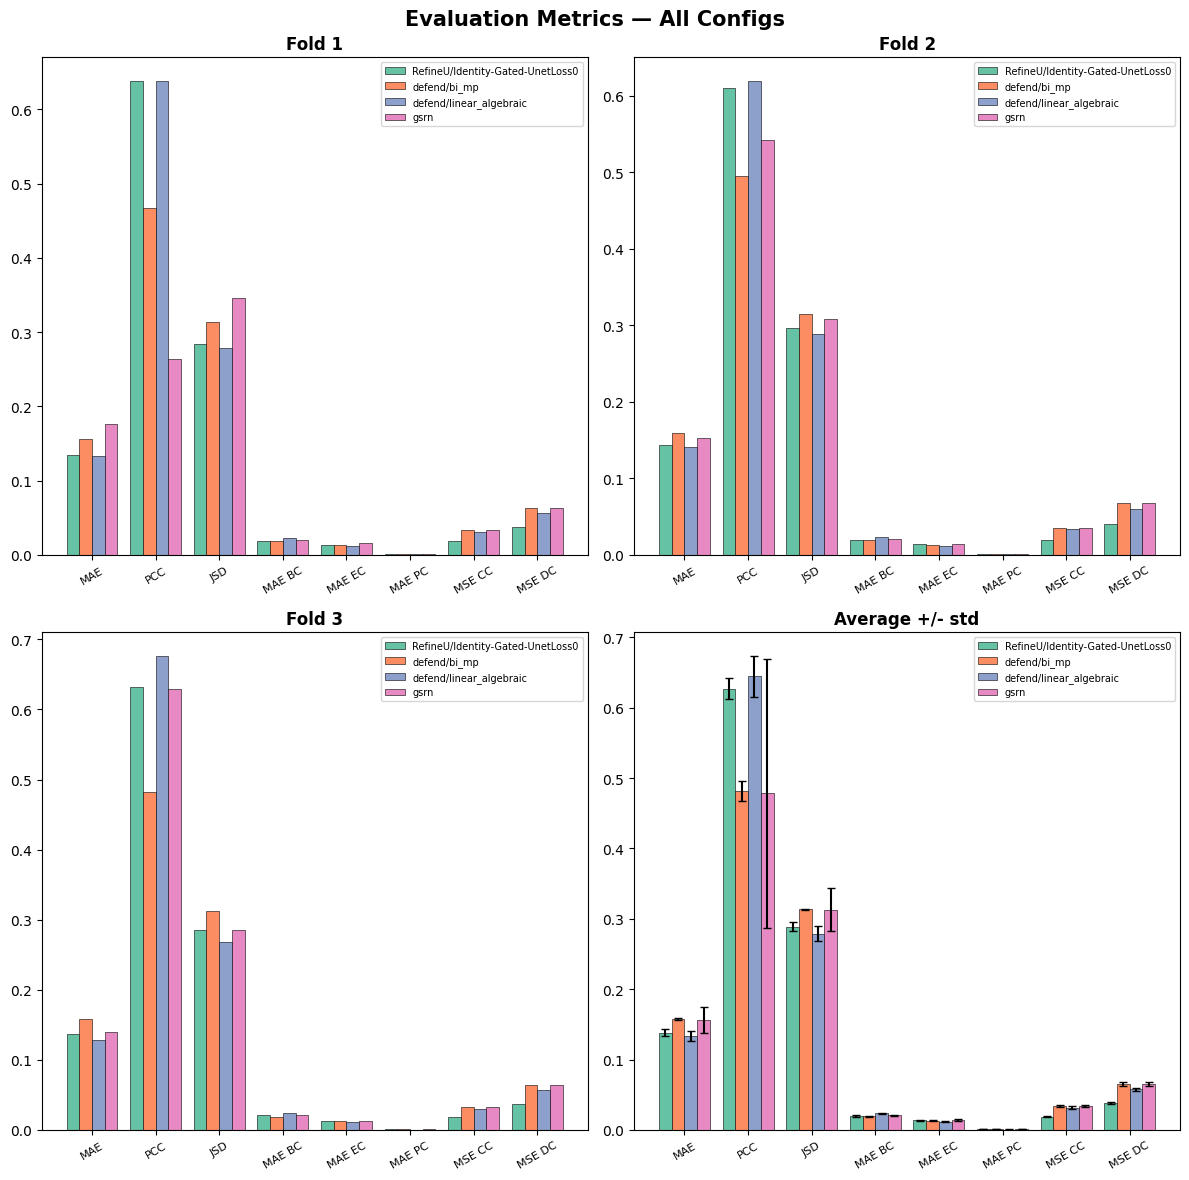

In [11]:
METRIC_NAMES = ["MAE", "PCC", "JSD", "BC", "EC", "PC", "CC", "DC"]
METRIC_LABELS = {
    "MAE": "MAE", "PCC": "PCC", "JSD": "JSD",
    "BC": "MAE BC", "EC": "MAE EC", "PC": "MAE PC",
    "CC": "MSE CC", "DC": "MSE DC",
}


def build_eval_dataframe(results):
    """Convert nested results dict into long-form DataFrame."""
    rows = []
    for cfg, folds in results.items():
        for fold_key, metrics in folds.items():
            fold_num = int(fold_key.split("_")[1])
            for m in METRIC_NAMES:
                rows.append({
                    "config": cfg, "fold": fold_num,
                    "fold_label": f"Fold {fold_num}",
                    "metric": m, "value": metrics[m],
                })
    return pd.DataFrame(rows)


def plot_evaluation(df, save_path=None):
    """
    2x2 figure: 3 fold subplots + 1 average (mean +/- std).
    Grouped bars — one group per metric, one bar per config.
    Same layout as evaluation_plots.ipynb.
    """
    folds = sorted(df["fold"].unique())
    configs = sorted(df["config"].unique())
    n_metrics = len(METRIC_NAMES)
    n_configs = len(configs)
    palette = sns.color_palette("Set2", n_colors=n_configs)
    bar_width = 0.8 / n_configs
    x_base = np.arange(n_metrics)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    # Per-fold subplots
    for idx, fold in enumerate(folds[:3]):
        ax = axes[idx]
        for j, cfg in enumerate(configs):
            vals = []
            for m in METRIC_NAMES:
                sub = df[(df["metric"] == m) & (df["fold"] == fold) & (df["config"] == cfg)]
                vals.append(sub["value"].values[0] if len(sub) else 0)
            offset = (j - n_configs / 2 + 0.5) * bar_width
            ax.bar(x_base + offset, vals, width=bar_width,
                   color=palette[j], edgecolor="black", linewidth=0.4, label=cfg)
        ax.set_xticks(x_base)
        ax.set_xticklabels([METRIC_LABELS[m] for m in METRIC_NAMES], rotation=30, ha="center", fontsize=8)
        ax.set_title(f"Fold {fold}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=7, loc="upper right")

    # Average subplot (mean +/- std)
    ax_avg = axes[3]
    for j, cfg in enumerate(configs):
        means, stds = [], []
        for m in METRIC_NAMES:
            v = df[(df["metric"] == m) & (df["config"] == cfg)]["value"]
            means.append(v.mean())
            stds.append(v.std())
        offset = (j - n_configs / 2 + 0.5) * bar_width
        ax_avg.bar(x_base + offset, means, yerr=stds, width=bar_width,
                   capsize=3, color=palette[j], edgecolor="black", linewidth=0.4, label=cfg)
    ax_avg.set_xticks(x_base)
    ax_avg.set_xticklabels([METRIC_LABELS[m] for m in METRIC_NAMES], rotation=30, ha="center", fontsize=8)
    ax_avg.set_title("Average +/- std", fontsize=12, fontweight="bold")
    ax_avg.legend(fontsize=7, loc="upper right")

    for i in range(len(folds), 3):
        axes[i].set_visible(False)

    fig.suptitle("Evaluation Metrics — All Configs", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 1.0])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {save_path}")
    plt.show()


# ── Compute or load ──────────────────────────────────────────────────────────

if RUN_EVAL:
    print("Computing full evaluation metrics (this may take a few minutes)...")
    all_fold_metrics = []
    for fold_i, (fold_preds, fold_gts) in enumerate(all_fold_pred_matrices):
        print(f"  Fold {fold_i+1}:", end="")
        fold_metrics = compute_full_evaluation(fold_preds, fold_gts)
        all_fold_metrics.append(fold_metrics)
        print("done")
        print("    " + "  ".join(f"{k}={v:.5f}" for k, v in fold_metrics.items()))

    avg_metrics = {k: np.mean([m[k] for m in all_fold_metrics]) for k in all_fold_metrics[0]}
    std_metrics = {k: np.std([m[k] for m in all_fold_metrics]) for k in all_fold_metrics[0]}
    print(f"\n  Average: " + "  ".join(f"{k}={v:.5f}" for k, v in avg_metrics.items()))
    print(f"  Std:     " + "  ".join(f"{k}={v:.5f}" for k, v in std_metrics.items()))

    # Wrap into same format as JSON for unified plotting
    all_results = {"RefineU-B-Gated (this run)": {
        f"fold_{i+1}": m for i, m in enumerate(all_fold_metrics)
    }}

else:
    # Load precomputed results from evaluation_results.json
    with open("evaluation_results.json", "r") as f:
        all_results = json.load(f)
    print("Loaded precomputed metrics from evaluation_results.json")

# Summary table
rows = []
for config_name, folds in all_results.items():
    fold_metrics_list = list(folds.values())
    avg = {k: np.mean([f[k] for f in fold_metrics_list]) for k in fold_metrics_list[0]}
    std = {k: np.std([f[k] for f in fold_metrics_list]) for k in fold_metrics_list[0]}
    row = {"Model": config_name}
    for k in avg:
        row[METRIC_LABELS.get(k, k)] = f"{avg[k]:.4f} +/- {std[k]:.4f}"
    rows.append(row)
print(pd.DataFrame(rows).set_index("Model").to_string())

# Plot (same layout as evaluation_plots.ipynb)
df_eval = build_eval_dataframe(all_results)
plot_evaluation(df_eval, save_path="all_metrics_copy.png")

## 10. Visualization — Distribution & Heatmaps

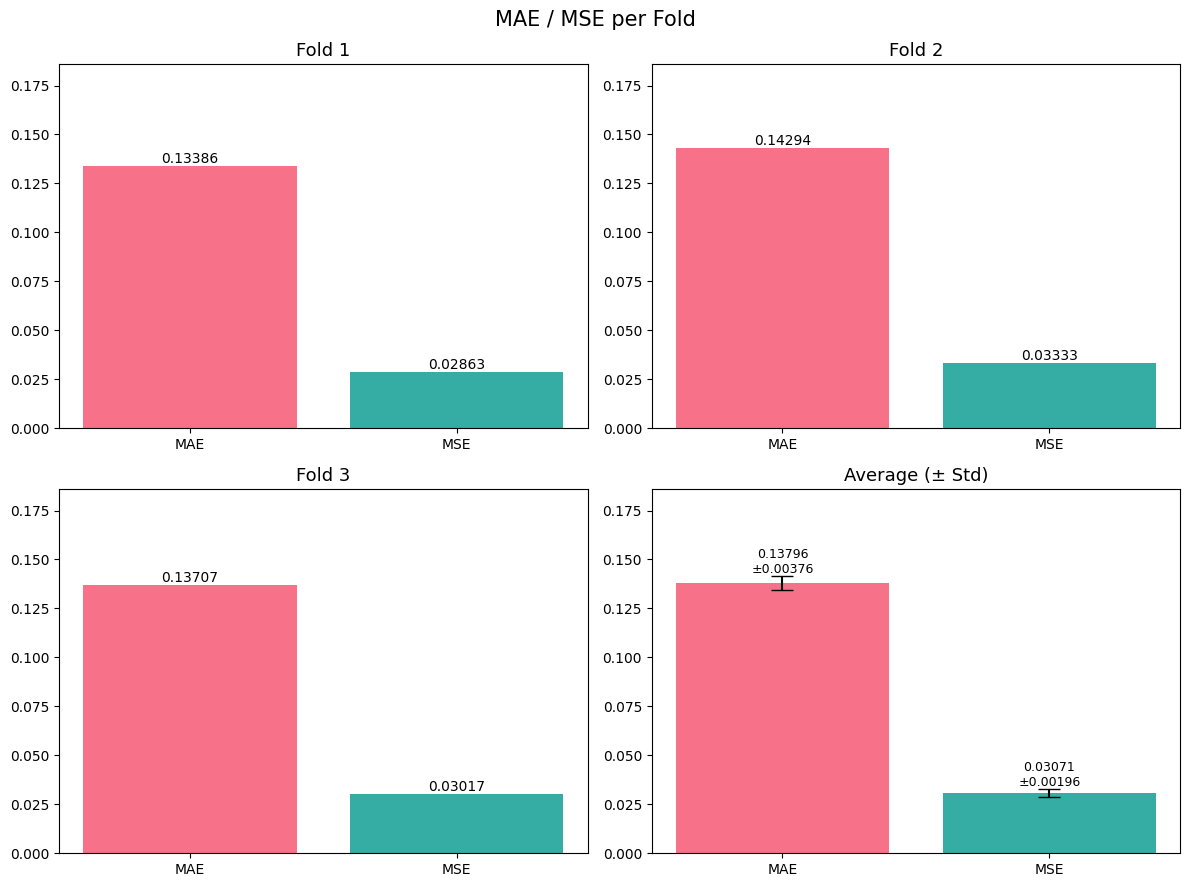

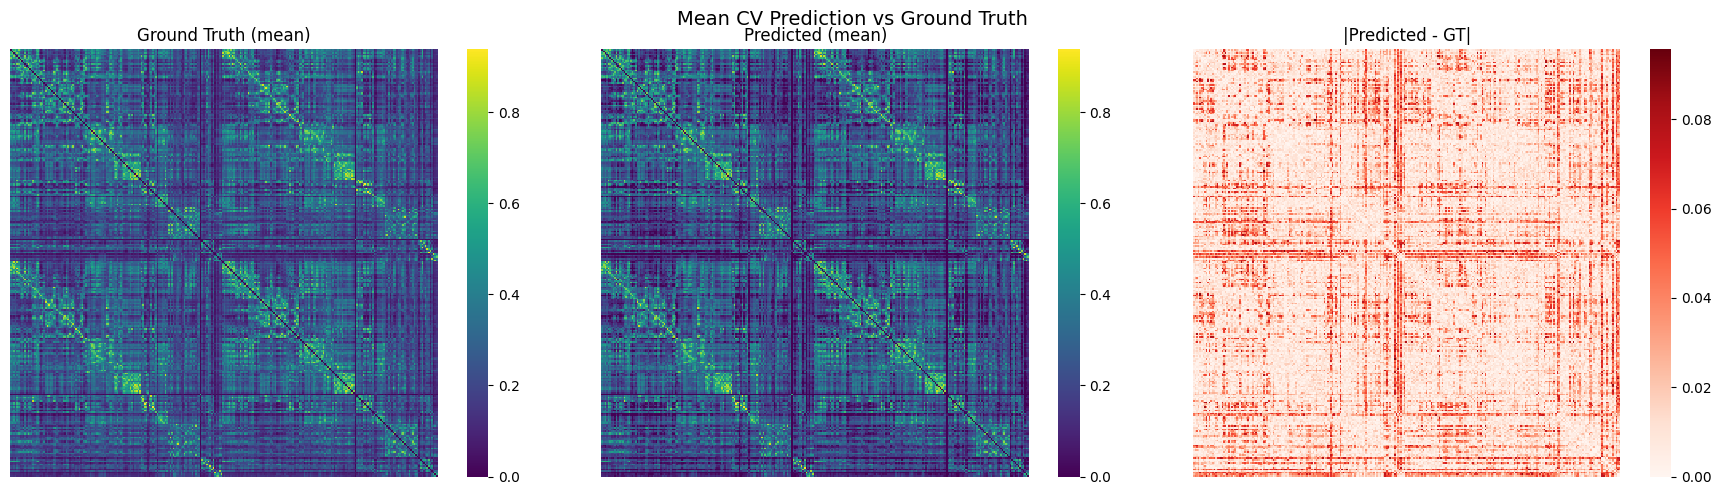

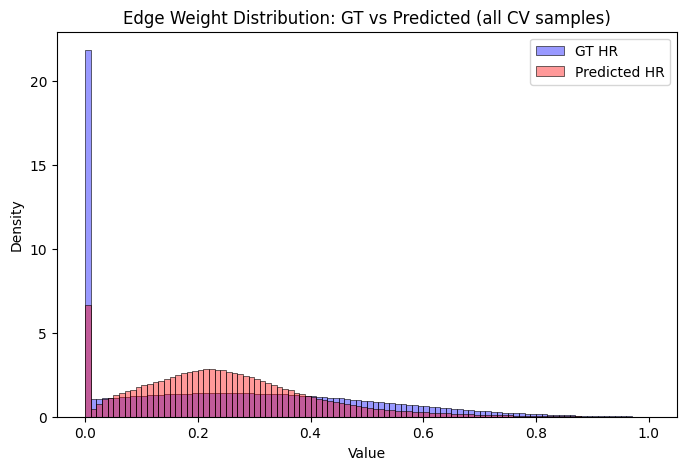

In [12]:
# ---------------------------------------------------------------------------
# MAE / MSE bar plot per fold + average
# ---------------------------------------------------------------------------
colors = sns.color_palette("husl", 2)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for i in range(N_SPLITS):
    row, col = divmod(i, 2)
    ax = axes[row][col]
    bars = ax.bar(["MAE", "MSE"], [fold_mae[i], fold_mse[i]], color=colors)
    ax.set_title(f"Fold {i+1}", fontsize=13)
    ax.set_ylim(0, max(max(fold_mae), max(fold_mse)) * 1.3)
    for bar, val in zip(bars, [fold_mae[i], fold_mse[i]]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{val:.5f}", ha="center", va="bottom")

ax = axes[1][1]
avg_mae, std_mae = np.mean(fold_mae), np.std(fold_mae)
avg_mse, std_mse = np.mean(fold_mse), np.std(fold_mse)
bars = ax.bar(["MAE", "MSE"], [avg_mae, avg_mse], yerr=[std_mae, std_mse], color=colors, capsize=8)
ax.set_title("Average (± Std)", fontsize=13)
ax.set_ylim(0, max(max(fold_mae), max(fold_mse)) * 1.3)
for bar, val, std in zip(bars, [avg_mae, avg_mse], [std_mae, std_mse]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std,
            f"{val:.5f}\n±{std:.5f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("MAE / MSE per Fold", fontsize=15)
fig.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Heatmap comparison: GT vs Predicted vs |Diff| (averaged across all CV samples)
# ---------------------------------------------------------------------------
all_preds = np.concatenate([p for p, g in all_fold_pred_matrices])
all_gts = np.concatenate([g for p, g in all_fold_pred_matrices])
mean_pred = np.mean(all_preds, axis=0)
mean_gt = np.mean(all_gts, axis=0)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
vmax = max(mean_gt.max(), mean_pred.max())

sns.heatmap(mean_gt, ax=ax1, cmap="viridis", square=True, vmin=0, vmax=vmax, xticklabels=False, yticklabels=False)
ax1.set_title("Ground Truth (mean)")
sns.heatmap(mean_pred, ax=ax2, cmap="viridis", square=True, vmin=0, vmax=vmax, xticklabels=False, yticklabels=False)
ax2.set_title("Predicted (mean)")
sns.heatmap(np.abs(mean_pred - mean_gt), ax=ax3, cmap="Reds", square=True, vmin=0, xticklabels=False, yticklabels=False)
ax3.set_title("|Predicted - GT|")

fig.suptitle("Mean CV Prediction vs Ground Truth", fontsize=14)
fig.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Distribution: GT vs Predicted
# ---------------------------------------------------------------------------
gt_flat = all_gts.flatten()
pred_flat = all_preds.flatten()

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(gt_flat, bins=100, color="blue", alpha=0.4, label="GT HR", ax=ax, stat="density")
sns.histplot(pred_flat, bins=100, color="red", alpha=0.4, label="Predicted HR", ax=ax, stat="density")
ax.set_title("Edge Weight Distribution: GT vs Predicted (all CV samples)")
ax.set_xlabel("Value")
ax.legend()
plt.show()

## 11. Generate Submission CSV

Ensemble predictions from all folds (averaged), clipped to [0, 1] to ensure no negative values.

In [13]:
# ---------------------------------------------------------------------------
# Ensemble: average predictions across folds, clip to [0, 1]
# ---------------------------------------------------------------------------
n_test = lr_matrices_test.shape[0]
pred_matrices = []
for i in range(n_test):
    avg = np.mean([fold_test_preds[f][i] for f in range(N_SPLITS)], axis=0)
    pred_matrices.append(np.clip(avg, 0.0, 1.0))

# ---------------------------------------------------------------------------
# Save per-fold HR prediction CSVs: predictions_fold_{fold_num}.csv
# ---------------------------------------------------------------------------
os.makedirs("outputs", exist_ok=True)

for fold_idx, (fold_preds, fold_gts) in enumerate(all_fold_pred_matrices):
    # Vectorize predictions
    pred_vecs = []
    for p in fold_preds:
        pred_vecs.append(MatrixVectorizer.vectorize(p, include_diagonal=False))
    pred_flat = np.concatenate(pred_vecs)
    pred_ids = np.arange(1, len(pred_flat) + 1)
    pred_df = pd.DataFrame({"ID": pred_ids, "Predicted": pred_flat})
    pred_path = f"predictions_fold_{fold_idx + 1}.csv"
    pred_df.to_csv(pred_path, index=False)

    print(f"Fold {fold_idx + 1}: saved {pred_path} ({len(pred_df)} rows)")

# ---------------------------------------------------------------------------
# Save final ensemble submission CSV
# ---------------------------------------------------------------------------
preds_vect = []
for pred in pred_matrices:
    preds_vect.append(MatrixVectorizer.vectorize(pred, include_diagonal=False))

preds_flat = np.concatenate(preds_vect)
ids = np.arange(1, len(preds_flat) + 1)

submission_df = pd.DataFrame({"ID": ids, "Predicted": preds_flat})
submission_path = "submission.csv"
submission_df.to_csv(submission_path, index=False)
print(f"\nSaved ensemble submission to {submission_path} ({len(submission_df)} rows)")
submission_df.head()

Fold 1: saved predictions_fold_1.csv (2003568 rows)
Fold 2: saved predictions_fold_2.csv (2003568 rows)
Fold 3: saved predictions_fold_3.csv (1967790 rows)

Saved ensemble submission to submission.csv (4007136 rows)


,ID,Predicted
0,1,0.561833
1,2,0.549324
2,3,0.693913
3,4,0.646507
4,5,0.666746
